# Practical Homework 1: Decision Trees

## Introduction
- This analysis examines factors associated with youth alcohol, specifically the question: *What factors are associated with youth alcohol use, and how well can we predict alcohol use behavior?*
    - To address this question, alcohol use is examined in three different forms: whether a youth has ever used alcohol, how frequently they use alcohol, and how many days they use alcohol over the course of a year.
- The data used is from the National Survey on Drug Use and Health (NSDUH).
    - The dataset used in this analysis is a pre-processed subset of the NSDUH data, filtered to include only respondents under the age of 18. It includes variables related to demographics, peer influence, family environment, school experiences, and substance use. Many variables are coded in multiple ways (binary, categorical, and numeric), allowing for comparison of how different representations of the same concept affect model performance.
- To investigate these questions, several tree-based machine learning methods are used. These include decision trees as baseline models, along with ensemble methods such as random forests, gradient boosting, and bagging. These methods are applied to three types of problems: binary classification, multi-class classification, and regression.

## Import and Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingRegressor, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error
from sklearn.metrics import balanced_accuracy_score


## Load and Inspect Data

### Loading and general inspection

In [3]:
df = pd.read_csv("youth_data.csv")

df.head()

,IRALCFY,IRMJFY,IRCIGFM,IRSMKLSS30N,IRALCFM,IRMJFM,IRCIGAGE,IRSMKLSSTRY,IRALCAGE,IRMJAGE,...,EDUSCHLGO,EDUSCHGRD2,EDUSKPCOM,IMOTHER,IFATHER,INCOME,GOVTPROG,POVERTY3,PDEN10,COUTYP4
0,991,991,91.0,91,91.0,91.0,991,991,991,991,...,1,3,0,1,1,2,2,1,2,2
1,991,60,91.0,91,91.0,2.0,991,991,991,14,...,1,6,0,1,1,2,2,1,2,2
2,1,991,91.0,91,93.0,91.0,991,991,11,991,...,1,2,1,1,1,4,2,3,1,1
3,991,991,91.0,91,91.0,91.0,991,991,991,991,...,1,2,0,1,1,3,2,2,1,1
4,991,991,91.0,91,91.0,91.0,991,991,991,991,...,1,5,0,1,1,4,2,3,2,2


In [4]:
print("Dataset info:")
df.info()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10561 entries, 0 to 10560
Data columns (total 79 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   IRALCFY      10561 non-null  int64  
 1   IRMJFY       10561 non-null  int64  
 2   IRCIGFM      10561 non-null  float64
 3   IRSMKLSS30N  10561 non-null  int64  
 4   IRALCFM      10561 non-null  float64
 5   IRMJFM       10561 non-null  float64
 6   IRCIGAGE     10561 non-null  int64  
 7   IRSMKLSSTRY  10561 non-null  int64  
 8   IRALCAGE     10561 non-null  int64  
 9   IRMJAGE      10561 non-null  int64  
 10  MRJFLAG      10561 non-null  int64  
 11  ALCFLAG      10561 non-null  int64  
 12  TOBFLAG      10561 non-null  int64  
 13  ALCYDAYS     10561 non-null  int64  
 14  MRJYDAYS     10561 non-null  int64  
 15  ALCMDAYS     10561 non-null  int64  
 16  MRJMDAYS     10561 non-null  int64  
 17  CIGMDAYS     10561 non-null  int64  
 18  SMKLSMDAYS   10561 non-null  int

In [5]:
missing_counts = df.isna().sum().sort_values(ascending = False)

missing_counts.head(15)

AVGGRADE    716
STNDDNK     550
STNDALC     454
STNDSMJ     445
STNDSCIG    377
TALKPROB    336
RLGFRND     322
RLGIMPT     321
RLGDCSN     297
RLGATTD     288
PRBSOLV2    286
PARLMTSN    259
PRTALK3     199
DRPRVME3    193
ARGUPAR     180
dtype: int64

### Key variable inspection

#### Alcohol Usage
- Alcohol - Ever Used (ALCFLAG)
    - 0 = Never used (IRALCRC = 9)
    - 1 = Used within the past year (IRALCRC = 1, 2)

In [6]:
print("ALCFLAG value counts:")

print(df['ALCFLAG'].value_counts(dropna = False))

ALCFLAG value counts:
ALCFLAG
0    8157
1    2404
Name: count, dtype: int64


#### Alcohol Frequency
- ALCOHOL FREQUENCY PAST MONTH - IMPUTATION REVISED (IRALCFM)
    - Range = 1 - 30
    - 91 = Never Used
    - 93 = Did not Use Alcohol Past Month

In [7]:
print("IRALCFM value counts:")

print(df['IRALCFM'].value_counts(dropna = False).sort_index())

IRALCFM value counts:
IRALCFM
1.0      281
1.5       10
2.0      166
3.0      101
4.0       52
5.0       46
6.0        9
7.0       14
7.5        1
8.0        5
9.0        2
10.0      18
11.0       1
12.0       6
14.0       2
15.0       9
16.0       2
17.0       1
20.0       1
21.0       1
27.0       1
28.0       2
30.0       3
91.0    8157
93.0    1670
Name: count, dtype: int64


#### Alcohol Frequency (2)
- ALCOHOL FREQUENCY PAST YEAR - IMPUTATION REVISED (IRALCFY)
    - Range = 1- 365
    - 991 = NEVER USED ALCOHOL
    - 993 = DID NOT USE ALCOHOL IN THE PAST 12 MOS


In [8]:
print("IRALCFY value counts (top 15):")
print(df['IRALCFY'].value_counts(dropna = False).head(15))

IRALCFY value counts (top 15):
IRALCFY
991    8157
993     539
1       326
2       221
3       190
5       121
12      113
24       99
52       90
4        87
36       71
6        54
48       43
10       40
8        38
Name: count, dtype: int64


## Data Cleaning and Preparation

In [9]:
df_clean = df.copy()

### Special Codes
- The codes listed will be recored so that nouse is represented as 0 and invalid responses are treated as missing.
- `IRALCFM`
    - 91 = Never used alcohol > 0
    - 93 = Did not use alcohol in the past month > 0
- `IRALCFY`
    - 991 = Never used alcohol > 0
    - 993 = Did not use alcohol in the past 12 months > 0

#### Alcohol Frequency Past Month (IRALCFM)

In [10]:
df_clean['IRALCFM'] = df_clean['IRALCFM'].replace({
    91: 0,   # never used alcohol
    93: 0    # did not use alcohol past month
})

print(df_clean['IRALCFM'].value_counts(dropna = False).sort_index())
df_clean['IRALCFM'].describe()

IRALCFM
0.0     9827
1.0      281
1.5       10
2.0      166
3.0      101
4.0       52
5.0       46
6.0        9
7.0       14
7.5        1
8.0        5
9.0        2
10.0      18
11.0       1
12.0       6
14.0       2
15.0       9
16.0       2
17.0       1
20.0       1
21.0       1
27.0       1
28.0       2
30.0       3
Name: count, dtype: int64


count    10561.000000
mean         0.215463
std          1.259715
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         30.000000
Name: IRALCFM, dtype: float64

#### Alcohol Frequency Past Year (IRALCFY)

In [11]:
df_clean['IRALCFY'] = df_clean['IRALCFY'].replace({
    991: 0,
    993: 0
})

print(df_clean['IRALCFY'].value_counts(dropna = False).sort_index().head(15))
df_clean['IRALCFY'].describe()

IRALCFY
0     8696
1      326
2      221
3      190
4       87
5      121
6       54
7       27
8       38
9       12
10      40
11      10
12     113
13      10
14      10
Name: count, dtype: int64


count    10561.000000
mean         3.958243
std         18.975554
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        339.000000
Name: IRALCFY, dtype: float64

### Binary Target Variable
- ALCFLAG indicates whether a respondent has ever used alcohol. This does not need recoding.

In [12]:
df_clean['ALCFLAG'].value_counts(dropna = False)

ALCFLAG
0    8157
1    2404
Name: count, dtype: int64

### Multi-class Target Variable
- IRALCFM needs to be converted into categorical levels representing frequency of alcohol use.
    - 0 = No use
    - 1 = Low use (1–5 days)
    - 2 = Moderate use (6–15 days)
    - 3 = High use (16–30 days)


In [13]:
def categorize_alc_freq(x):
    if x == 0:
        return 0
    elif 1 <= x <= 5:
        return 1
    elif 6 <= x <= 15:
        return 2
    elif 16 <= x <= 30:
        return 3
    else:
        return np.nan

df_clean['ALC_FREQ_CAT'] = df_clean['IRALCFM'].apply(categorize_alc_freq)

df_clean['ALC_FREQ_CAT'].value_counts(dropna = False).sort_index()

ALC_FREQ_CAT
0    9827
1     656
2      67
3      11
Name: count, dtype: int64

### Predictor Selection and modeling dataset
These are a reasonable first set because they reflect:

demographics
family environment
peer influence
school norms
behavior

and they avoid direct alcohol-use leakage.

In [14]:
# --- IGNORE ---
predictors = [
    'IRSEX', 'NEWRACE2', 'INCOME', 'POVERTY3',
    'PARCHKHW', 'PARHLPHW', 'PRPROUD2',
    'AVGGRADE', 'STNDALC', 'STNDSMJ',
    'FRDADLY2', 'FRDMJMON',
    'YOFIGHT2', 'YOSTOLE2'
]

model_vars = predictors + ['ALCFLAG', 'IRALCFM', 'ALC_FREQ_CAT', 'IRALCFY']

model_data = df_clean[model_vars].dropna()

print("Modeling dataset shape:", model_data.shape)

Modeling dataset shape: (9227, 18)


In [15]:
#Updated Code
# Predictor Exploration
predictors = [
    'IRSEX', 'NEWRACE2', 'INCOME', 'POVERTY3',
    'PARCHKHW', 'PARHLPHW', 'PRPROUD2',
    'AVGGRADE', 'STNDALC', 'STNDSMJ',
    'FRDADLY2', 'FRDMJMON',
    'YOFIGHT2', 'YOSTOLE2'
]

explore_rows = []

for col in predictors:
    explore_rows.append({
        "variable": col,
        "dtype": df_clean[col].dtype,
        "n_missing": df_clean[col].isna().sum(),
        "n_unique": df_clean[col].nunique(dropna=True),
        "min": df_clean[col].min(),
        "max": df_clean[col].max()
    })

exploration_df = pd.DataFrame(explore_rows)
exploration_df

,variable,dtype,n_missing,n_unique,min,max
0,IRSEX,int64,0,2,1.0,2.0
1,NEWRACE2,int64,0,7,1.0,7.0
2,INCOME,int64,0,4,1.0,4.0
3,POVERTY3,int64,0,3,1.0,3.0
4,PARCHKHW,float64,77,2,1.0,2.0
5,PARHLPHW,float64,89,2,1.0,2.0
6,PRPROUD2,float64,77,2,1.0,2.0
7,AVGGRADE,float64,716,2,1.0,2.0
8,STNDALC,float64,454,2,1.0,2.0
9,STNDSMJ,float64,445,2,1.0,2.0


In [16]:
# Updated Code
# Verify value counts for predictors
for col in predictors:
    print(f"\n=== {col} ===")
    print(df_clean[col].value_counts(dropna=False).sort_index().head(20))


=== IRSEX ===
IRSEX
1    5387
2    5174
Name: count, dtype: int64

=== NEWRACE2 ===
NEWRACE2
1    4750
2    1284
3     368
4      50
5     503
6     795
7    2811
Name: count, dtype: int64

=== INCOME ===
INCOME
1    1400
2    2766
3    1482
4    4913
Name: count, dtype: int64

=== POVERTY3 ===
POVERTY3
1    2433
2    2299
3    5829
Name: count, dtype: int64

=== PARCHKHW ===
PARCHKHW
1.0    8315
2.0    2169
NaN      77
Name: count, dtype: int64

=== PARHLPHW ===
PARHLPHW
1.0    8151
2.0    2321
NaN      89
Name: count, dtype: int64

=== PRPROUD2 ===
PRPROUD2
1.0    8488
2.0    1996
NaN      77
Name: count, dtype: int64

=== AVGGRADE ===
AVGGRADE
1.0     574
2.0    9271
NaN     716
Name: count, dtype: int64

=== STNDALC ===
STNDALC
1.0    2686
2.0    7421
NaN     454
Name: count, dtype: int64

=== STNDSMJ ===
STNDSMJ
1.0    2762
2.0    7354
NaN     445
Name: count, dtype: int64

=== FRDADLY2 ===
FRDADLY2
1.0    9277
2.0    1137
NaN     147
Name: count, dtype: int64

=== FRDMJMON ===
F

In [17]:
# Updated code
# Binary predictor variables
binary_vars = [
    'IRSEX', 'PARCHKHW', 'PARHLPHW', 'PRPROUD2',
    'STNDALC', 'STNDSMJ',
    'FRDADLY2', 'FRDMJMON',
    'YOFIGHT2', 'YOSTOLE2'
]

for col in binary_vars:
    df_clean[col] = df_clean[col].replace({1: 0, 2: 1})

In [18]:
# Updated Code
# Verify binary predictor variables
for col in binary_vars:
    print(f"\n=== {col} ===")
    print(df_clean[col].value_counts(dropna=False))


=== IRSEX ===
IRSEX
0    5387
1    5174
Name: count, dtype: int64

=== PARCHKHW ===
PARCHKHW
0.0    8315
1.0    2169
NaN      77
Name: count, dtype: int64

=== PARHLPHW ===
PARHLPHW
0.0    8151
1.0    2321
NaN      89
Name: count, dtype: int64

=== PRPROUD2 ===
PRPROUD2
0.0    8488
1.0    1996
NaN      77
Name: count, dtype: int64

=== STNDALC ===
STNDALC
1.0    7421
0.0    2686
NaN     454
Name: count, dtype: int64

=== STNDSMJ ===
STNDSMJ
1.0    7354
0.0    2762
NaN     445
Name: count, dtype: int64

=== FRDADLY2 ===
FRDADLY2
0.0    9277
1.0    1137
NaN     147
Name: count, dtype: int64

=== FRDMJMON ===
FRDMJMON
0.0    8222
1.0    2187
NaN     152
Name: count, dtype: int64

=== YOFIGHT2 ===
YOFIGHT2
1.0    8774
0.0    1720
NaN      67
Name: count, dtype: int64

=== YOSTOLE2 ===
YOSTOLE2
1.0    10094
0.0      427
NaN       40
Name: count, dtype: int64


### One-hot encoding

In [19]:
### One-hot encode nominal variables

df_encoded = pd.get_dummies(df_clean, columns = ['NEWRACE2'], drop_first = True)
print(df_encoded.filter(like = 'NEWRACE2').columns.tolist())

['NEWRACE2_2', 'NEWRACE2_3', 'NEWRACE2_4', 'NEWRACE2_5', 'NEWRACE2_6', 'NEWRACE2_7']


In [20]:
race_cols = [col for col in df_encoded.columns if col.startswith('NEWRACE2_')]

df_encoded[race_cols] = df_encoded[race_cols].astype(int)

### Build modeling dataset

In [21]:
# Drop rows with missing values in variables needed for modeling
model_data = df_encoded.dropna(subset = [
    'ALCFLAG', 'ALC_FREQ_CAT', 'IRALCFY',
    'IRSEX', 'INCOME', 'POVERTY3',
    'PARCHKHW', 'PARHLPHW', 'PRPROUD2',
    'AVGGRADE', 'STNDALC', 'STNDSMJ',
    'FRDADLY2', 'FRDMJMON',
    'YOFIGHT2', 'YOSTOLE2',
    'NEWRACE2_2', 'NEWRACE2_3', 'NEWRACE2_4',
    'NEWRACE2_5', 'NEWRACE2_6', 'NEWRACE2_7'
])

# Define predictor columns after encoding
predictor_cols = [
    'IRSEX', 'INCOME', 'POVERTY3',
    'PARCHKHW', 'PARHLPHW', 'PRPROUD2',
    'AVGGRADE', 'STNDALC', 'STNDSMJ',
    'FRDADLY2', 'FRDMJMON',
    'YOFIGHT2', 'YOSTOLE2',
    'NEWRACE2_2', 'NEWRACE2_3', 'NEWRACE2_4',
    'NEWRACE2_5', 'NEWRACE2_6', 'NEWRACE2_7'
]

# Define predictor matrix and target variables
X = model_data[predictor_cols]

y_binary = model_data['ALCFLAG']
y_multi = model_data['ALC_FREQ_CAT']
y_reg = model_data['IRALCFY']

print("model_data shape:", model_data.shape)
print("X shape:", X.shape)
print("y_binary shape:", y_binary.shape)
print("y_multi shape:", y_multi.shape)
print("y_reg shape:", y_reg.shape)

model_data shape: (9227, 85)
X shape: (9227, 19)
y_binary shape: (9227,)
y_multi shape: (9227,)
y_reg shape: (9227,)


In [22]:
print(X.dtypes)
print("\n")
print(X.head())

IRSEX           int64
INCOME          int64
POVERTY3        int64
PARCHKHW      float64
PARHLPHW      float64
PRPROUD2      float64
AVGGRADE      float64
STNDALC       float64
STNDSMJ       float64
FRDADLY2      float64
FRDMJMON      float64
YOFIGHT2      float64
YOSTOLE2      float64
NEWRACE2_2      int32
NEWRACE2_3      int32
NEWRACE2_4      int32
NEWRACE2_5      int32
NEWRACE2_6      int32
NEWRACE2_7      int32
dtype: object


   IRSEX  INCOME  POVERTY3  PARCHKHW  PARHLPHW  PRPROUD2  AVGGRADE  STNDALC  \
0      0       2         1       0.0       0.0       0.0       2.0      1.0   
1      1       2         1       0.0       0.0       0.0       2.0      0.0   
2      0       4         3       0.0       0.0       0.0       2.0      1.0   
4      0       4         3       1.0       0.0       0.0       2.0      1.0   
5      0       3         3       0.0       0.0       1.0       2.0      1.0   

   STNDSMJ  FRDADLY2  FRDMJMON  YOFIGHT2  YOSTOLE2  NEWRACE2_2  NEWRACE2_3  \
0      1.0   

## Binary Classification Model
In this section, I build classification models to predict whether a youth has ever used alcohol. The target variable is `ALCFLAG`, where 0 indicates never used alcohol and 1 indicates ever used alcohol.

I begin with a single decision tree as a baseline model, then compare it to a random forest to see whether an ensemble method improves predictive performance.

To evaluate the models, I use:
- Accuracy
- Confusion matrices
- Feature importance

### Single Decision Tree

In [23]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size = 0.3, random_state = 1, stratify = y_binary
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (6458, 19)
Test set size: (2769, 19)


In [24]:
# Tune the decision tree using cross-validation
tree_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.05]
}

tree_grid = GridSearchCV(
    estimator = DecisionTreeClassifier(random_state = 1),
    param_grid=tree_param_grid,
    cv = 5,
    scoring = 'balanced_accuracy',
    n_jobs = -1
)

tree_grid.fit(X_train, y_train)

best_tree_clf = tree_grid.best_estimator_

print("Best parameters:", tree_grid.best_params_)
print("Best CV score:", round(tree_grid.best_score_, 4))

Best parameters: {'ccp_alpha': 0.0, 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV score: 0.6506


In [25]:
# Generate predictions on the test set
y_pred_tree = best_tree_clf.predict(X_test)

# Calculate accuracy of the tuned decision tree model
tree_acc = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", round(tree_acc, 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.7916

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.95      0.87      2102
           1       0.66      0.28      0.40       667

    accuracy                           0.79      2769
   macro avg       0.73      0.62      0.63      2769
weighted avg       0.77      0.79      0.76      2769



In [26]:
print("Balanced Accuracy:", round(balanced_accuracy_score(y_test, y_pred_tree), 4))

Balanced Accuracy: 0.6181


In [27]:
# Create confusion matrix
tree_cm = confusion_matrix(y_test, y_pred_tree)

print("Decision Tree Confusion Matrix:")
print(tree_cm)

Decision Tree Confusion Matrix:
[[2003   99]
 [ 478  189]]


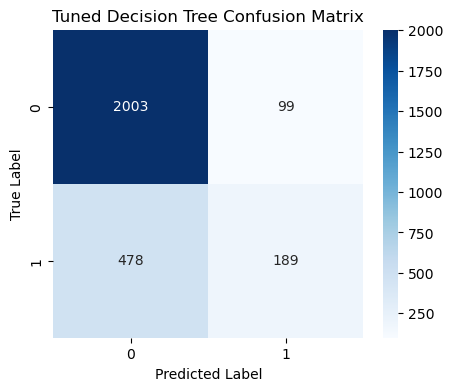

In [28]:
# Plot the confusion matrix as a heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(tree_cm, annot = True, fmt = 'd', cmap = 'Blues')

plt.title("Tuned Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

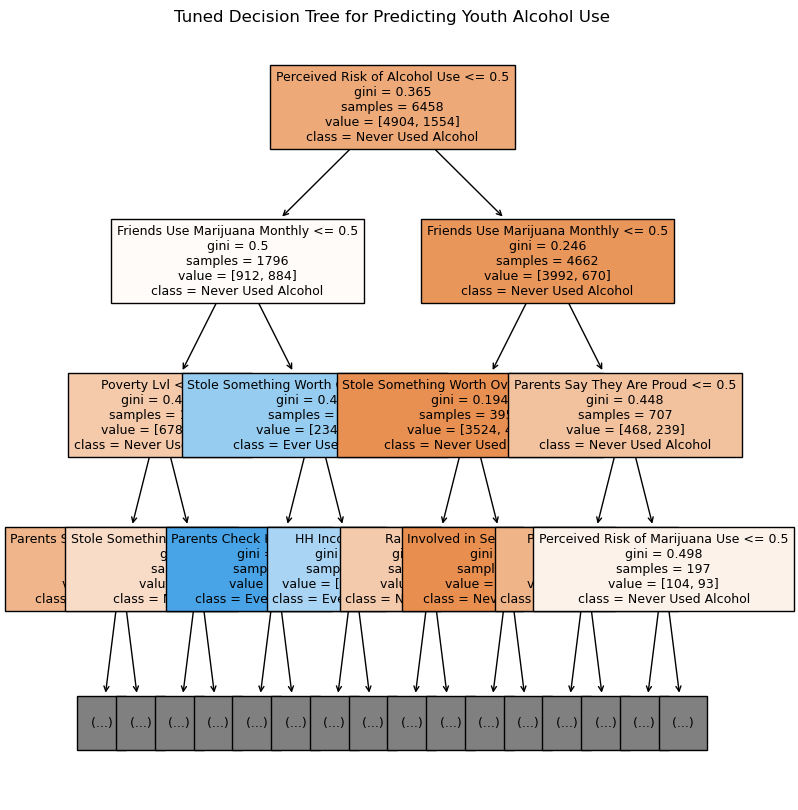

In [29]:
names = {
    'IRSEX': 'Sex',
    'INCOME': 'HH Income',
    'POVERTY3': 'Poverty Lvl',
    'PARCHKHW': 'Parents Check Homework',
    'PARHLPHW': 'Parents Help with Homework',
    'PRPROUD2': 'Parents Say They Are Proud',
    'AVGGRADE': 'Avg Grade in School',
    'STNDALC': 'Perceived Risk of Alcohol Use',
    'STNDSMJ': 'Perceived Risk of Marijuana Use',
    'FRDADLY2': 'Friends Use Alcohol Daily',
    'FRDMJMON': 'Friends Use Marijuana Monthly',
    'YOFIGHT2': 'Involved in Serious Fight',
    'YOSTOLE2': 'Stole Something Worth Over $50',
    'NEWRACE2_2': 'Race 2',
    'NEWRACE2_3': 'Race 3',
    'NEWRACE2_4': 'Race 4',
    'NEWRACE2_5': 'Race 5',
    'NEWRACE2_6': 'Race 6',
    'NEWRACE2_7': 'Race 7'
}

feature_names = [names[col] for col in X.columns]

plt.figure(figsize = (8, 10))
plot_tree(
    best_tree_clf,
    feature_names = feature_names,
    class_names = ['Never Used Alcohol', 'Ever Used Alcohol'],
    filled = True,
    max_depth = 3,
    fontsize = 9
)
plt.title("Tuned Decision Tree for Predicting Youth Alcohol Use")
plt.show()

### Random Forest

In [30]:
# Tune the random forest using cross-validation
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

rf_grid = GridSearchCV(
    estimator = RandomForestClassifier(random_state = 1),
    param_grid = rf_param_grid,
    cv = 5,
    scoring = 'balanced_accuracy',
    n_jobs = -1
)

rf_grid.fit(X_train, y_train)

best_rf_clf = rf_grid.best_estimator_

print("Best parameters:", rf_grid.best_params_)
print("Best CV score:", round(rf_grid.best_score_, 4))

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best CV score: 0.658


In [31]:
# Generate predictions on the test set
y_pred_rf = best_rf_clf.predict(X_test)

In [32]:
# Calculate accuracy for the tuned random forest model
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_acc, 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7952

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.94      0.87      2102
           1       0.64      0.34      0.44       667

    accuracy                           0.80      2769
   macro avg       0.73      0.64      0.66      2769
weighted avg       0.78      0.80      0.77      2769



In [33]:
print("Balanced Accuracy:", round(balanced_accuracy_score(y_test, y_pred_rf), 4))

Balanced Accuracy: 0.6394


In [34]:
# Create the confusion matrix
rf_cm = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[1976  126]
 [ 441  226]]


In [35]:
# Extract feature importance values
feature_importance = pd.Series(best_rf_clf.feature_importances_, index = X.columns)

# Sort from most to least important
feature_importance = feature_importance.sort_values(ascending = False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

Top 10 Most Important Features:
STNDALC     0.194102
FRDMJMON    0.164659
STNDSMJ     0.100315
INCOME      0.070710
YOSTOLE2    0.055614
POVERTY3    0.052530
YOFIGHT2    0.038891
FRDADLY2    0.038805
PARHLPHW    0.037613
PRPROUD2    0.037609
dtype: float64


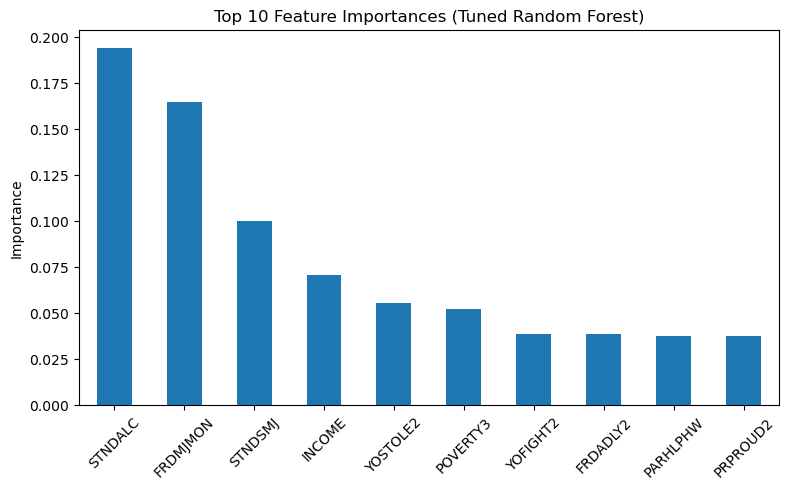

In [36]:
# Plot top 10 features
plt.figure(figsize = (8, 5))
feature_importance.head(10).plot(kind = 'bar')

plt.title("Top 10 Feature Importances (Tuned Random Forest)")
plt.ylabel("Importance")
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

### Summary

In [37]:
# Compare the two binary classification models
print("Decision Tree Accuracy:", round(tree_acc, 4))
print("Random Forest Accuracy:", round(rf_acc, 4))

Decision Tree Accuracy: 0.7916
Random Forest Accuracy: 0.7952


- The decision tree achieved an accuracy of 0.7916, while the random forest achieved an accuracy of 0.7952 Accuracy represents the proportion of correct predictions made by the model, so this means the random forest correctly classified whether a youth had ever used alcohol about 79% of the time.

- The improvement from the random forest was modest, suggesting that while combining multiple trees helped reduce overfitting, the single decision tree already captured much of the underlying pattern in the data.

- The confusion matrices show that both models were better at identifying youth who had never used alcohol than those who had used alcohol indicating that the models are biased toward the majority class.

- Feature importance from the random forest suggests that peer influence, perceived risk of substance use, socioeconomic variables, and family-related variables were among the most important predictors of alcohol use. This highlights that youth alcohol use is associated with a combination of social environment, attitudes, and background factors rather than a single dominant influence.

## Multi-Class Classification Model
In this section, I predict the frequency of youth alcohol use using the categorical target variable `ALC_FREQ_CAT`. This variable was created from `IRALCFM` and groups alcohol use in the past month into four levels:

- 0 = No use
- 1 = Low use (1–5 days)
- 2 = Moderate use (6–15 days)
- 3 = High use (16–30 days)

I begin with a single decision tree classifier as a baseline model and then compare it to a gradient boosting classifier.

### Decision Tree Model

In [38]:
# Define predictors and multi-class target
X = model_data[predictor_cols]
y_multi = model_data['ALC_FREQ_CAT']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_multi, test_size = 0.3, random_state = 1, stratify = y_multi
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (6458, 19)
Test set size: (2769, 19)


In [39]:
# Tune the multi-class decision tree using cross-validation
tree_multi_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.05]
}

tree_multi_grid = GridSearchCV(
    estimator = DecisionTreeClassifier(random_state = 1),
    param_grid = tree_multi_param_grid,
    cv = 5,
    scoring = 'balanced_accuracy',
    n_jobs = -1
)

tree_multi_grid.fit(X_train, y_train)

best_tree_multi = tree_multi_grid.best_estimator_

print("Best parameters:", tree_multi_grid.best_params_)
print("Best CV score:", round(tree_multi_grid.best_score_, 4))

Best parameters: {'ccp_alpha': 0.0, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV score: 0.2823


In [40]:
# Generate predictions on the test set
y_pred_tree_multi = best_tree_multi.predict(X_test)

# Calculate accuracy
tree_multi_acc = accuracy_score(y_test, y_pred_tree_multi)

print("Decision Tree Accuracy:", round(tree_multi_acc, 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree_multi))

Decision Tree Accuracy: 0.8967

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95      2563
           1       0.20      0.14      0.16       185
           2       0.00      0.00      0.00        18
           3       0.00      0.00      0.00         3

    accuracy                           0.90      2769
   macro avg       0.28      0.27      0.28      2769
weighted avg       0.88      0.90      0.89      2769



c:\Users\Travis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Travis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Travis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [41]:
print("Balanced Accuracy:", round(balanced_accuracy_score(y_test, y_pred_tree_multi), 4))

Balanced Accuracy: 0.2748


In [42]:
# Create the confusion matrix
tree_multi_cm = confusion_matrix(y_test, y_pred_tree_multi)

print("Decision Tree Confusion Matrix:")
print(tree_multi_cm)

Decision Tree Confusion Matrix:
[[2457  100    6    0]
 [ 156   26    3    0]
 [  14    4    0    0]
 [   1    2    0    0]]


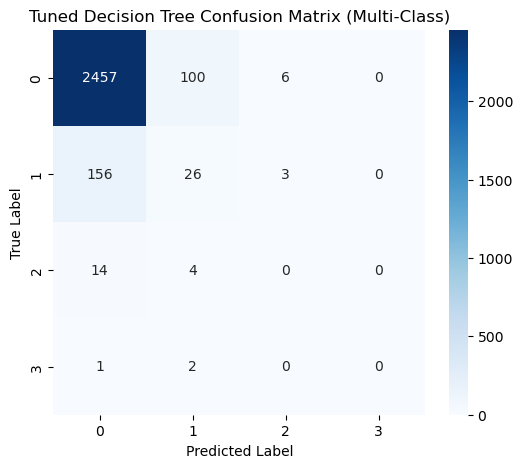

In [43]:
# Plot the confusion matrix as a heatmap
plt.figure(figsize = (6, 5))
sns.heatmap(tree_multi_cm, annot = True, fmt = 'd', cmap = 'Blues')

plt.title("Tuned Decision Tree Confusion Matrix (Multi-Class)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

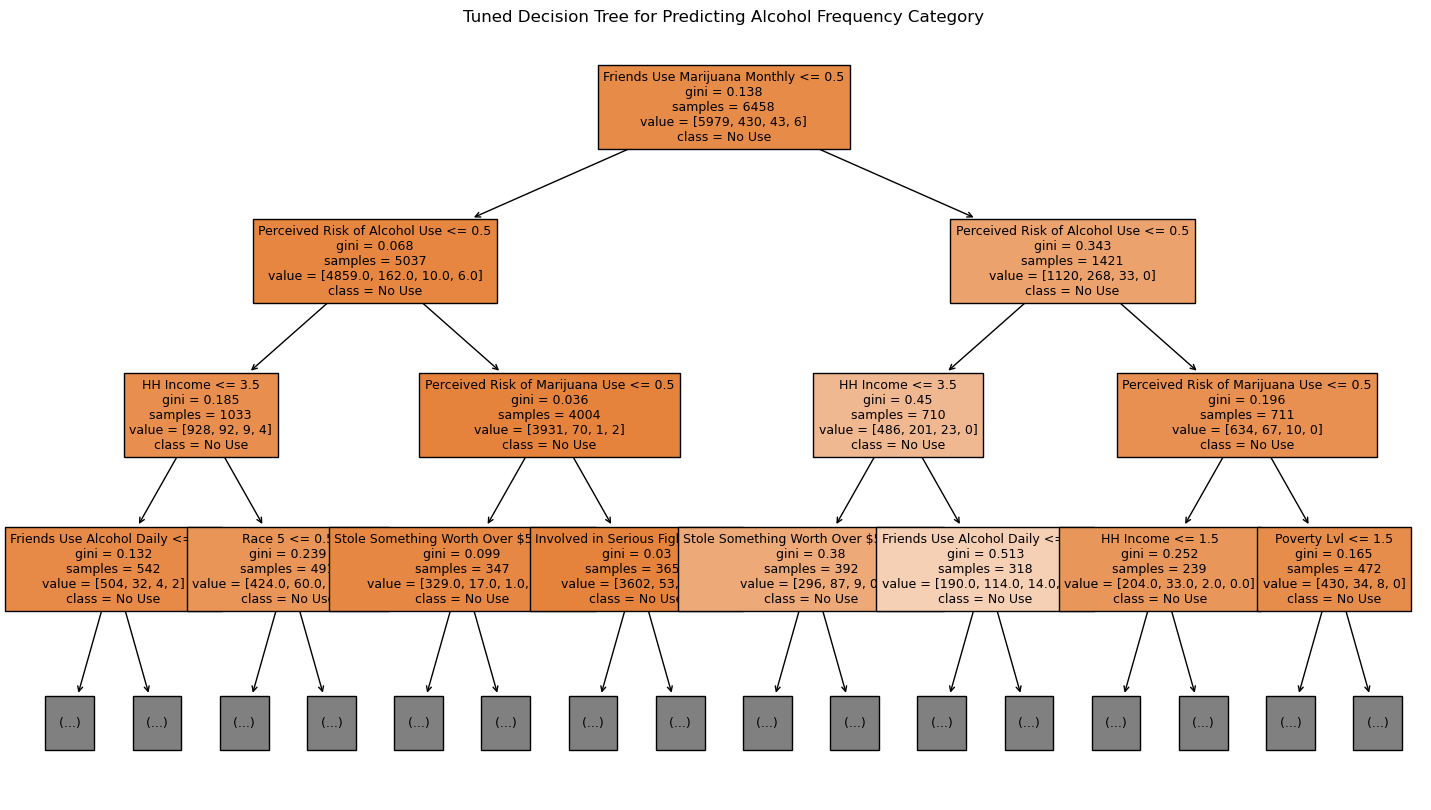

In [44]:
# Plot the first few levels of the tuned multi-class decision tree
plt.figure(figsize = (18, 10))
plot_tree(
    best_tree_multi,
    feature_names = feature_names,
    class_names = ['No Use', 'Low Use', 'Moderate Use', 'High Use'],
    filled = True,
    max_depth = 3,
    fontsize = 9
)

plt.title("Tuned Decision Tree for Predicting Alcohol Frequency Category")
plt.show()

### Gradient Boosting Model

In [45]:
# Tune the gradient boosting classifier using cross-validation
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

gb_grid = GridSearchCV(
    estimator = GradientBoostingClassifier(random_state = 1),
    param_grid = gb_param_grid,
    cv = 5,
    scoring = 'balanced_accuracy',
    n_jobs = -1
)

gb_grid.fit(X_train, y_train)

best_gb = gb_grid.best_estimator_

print("Best parameters:", gb_grid.best_params_)
print("Best CV score:", round(gb_grid.best_score_, 4))

Best parameters: {'learning_rate': 0.2, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best CV score: 0.2735


In [46]:
# Generate predictions on the test set
y_pred_gb = best_gb.predict(X_test)

# Calculate accuracy
gb_acc = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", round(gb_acc, 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9112

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95      2563
           1       0.22      0.09      0.13       185
           2       0.00      0.00      0.00        18
           3       0.00      0.00      0.00         3

    accuracy                           0.91      2769
   macro avg       0.29      0.27      0.27      2769
weighted avg       0.88      0.91      0.89      2769



c:\Users\Travis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Travis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Travis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [47]:
print("Balanced Accuracy:", round(balanced_accuracy_score(y_test, y_pred_gb), 4))

Balanced Accuracy: 0.2674


In [48]:
# Create the confusion matrix
gb_cm = confusion_matrix(y_test, y_pred_gb)

print("Gradient Boosting Confusion Matrix:")
print(gb_cm)

Gradient Boosting Confusion Matrix:
[[2506   54    3    0]
 [ 166   17    2    0]
 [  14    4    0    0]
 [   1    2    0    0]]


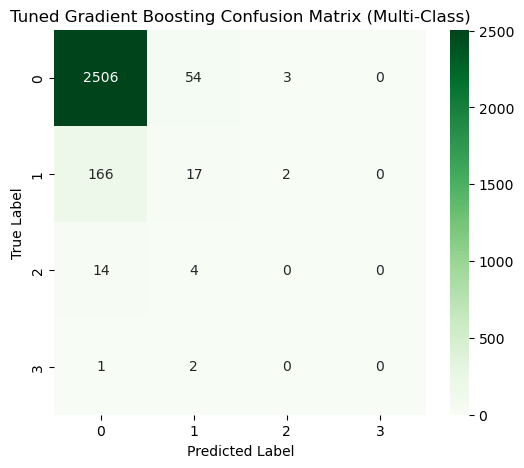

In [49]:
# Plot the confusion matrix as a heatmap
plt.figure(figsize = (6, 5))
sns.heatmap(gb_cm, annot = True, fmt = 'd', cmap = 'Greens')

plt.title("Tuned Gradient Boosting Confusion Matrix (Multi-Class)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [50]:
# Extract feature importance values from tuned gradient boosting
gb_importance = pd.Series(best_gb.feature_importances_, index = X.columns)

# Sort from most to least important
gb_importance = gb_importance.sort_values(ascending = False)

print("Top 10 Most Important Features:")
print(gb_importance.head(10))

Top 10 Most Important Features:
FRDMJMON      0.169119
STNDALC       0.134341
INCOME        0.094125
IRSEX         0.074318
NEWRACE2_7    0.069411
YOFIGHT2      0.064039
PARCHKHW      0.052917
FRDADLY2      0.050569
YOSTOLE2      0.047483
POVERTY3      0.046961
dtype: float64


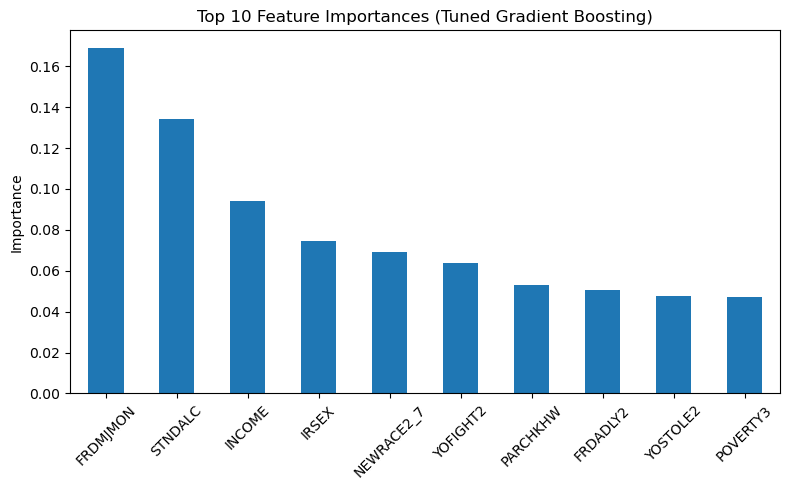

In [51]:
# Plot top 10 feature importances
plt.figure(figsize = (8, 5))
gb_importance.head(10).plot(kind = 'bar')

plt.title("Top 10 Feature Importances (Tuned Gradient Boosting)")
plt.ylabel("Importance")
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

### Summary
- Although both models achieved high accuracy (approximately 0.89 for the decision tree and 0.92 for gradient boosting), accuracy represents the proportion of correct predictions and can be misleading in imbalanced datasets.
- The confusion matrices reveal that most predictions are concentrated in the "No Use" category, which is the majority class in the data. This means the models may be heavily influenced by class imbalance and tend to predict the most common outcome.
- As a result, the high accuracy does not necessarily indicate strong performance across all categories. While the models perform well at identifying non-users, they struggle to distinguish between low, moderate, and high levels of alcohol use among users.
- This highlights an important limitation of multi-class classification in imbalanced datasets: accuracy alone may overstate model performance and should be interpreted alongside the confusion matrix.

## Regression Model
In this section, I predict the number of days a youth used alcohol in the past year using `IRALCFY` as the target variable. This variable represents a continuous measure of alcohol use frequency after recoding non-use values to 0.

I begin with a decision tree regressor as a baseline model and then compare it to a bagging regressor to evaluate whether an ensemble method improves predictive performance.

In [52]:
# Define predictors and regression target
X = model_data[predictor_cols]
y_reg = model_data['IRALCFY']

In [53]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size = 0.3, random_state = 1
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (6458, 19)
Test set size: (2769, 19)


In [54]:
# Tune the decision tree regressor using cross-validation
tree_reg_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.05]
}

tree_reg_grid = GridSearchCV(
    estimator = DecisionTreeRegressor(random_state = 1),
    param_grid = tree_reg_param_grid,
    cv = 5,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = -1
)

tree_reg_grid.fit(X_train, y_train)

best_tree_reg = tree_reg_grid.best_estimator_

print("Best parameters:", tree_reg_grid.best_params_)
print("Best CV RMSE:", round(-tree_reg_grid.best_score_, 4))

Best parameters: {'ccp_alpha': 0.0, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV RMSE: 17.9997


In [55]:
# Predict on test set
y_pred_tree_reg = best_tree_reg.predict(X_test)

# Calculate RMSE
tree_mse = mean_squared_error(y_test, y_pred_tree_reg)
tree_rmse = np.sqrt(tree_mse)

print("Decision Tree RMSE:", round(tree_rmse, 4))

Decision Tree RMSE: 20.4466


### Bagging Model

In [56]:
# Tune the bagging regressor using cross-validation
bag_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_samples': [0.5, 0.7, 1.0],
    'estimator__max_depth': [3, 5, 10, None],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 5]
}

bag_grid = GridSearchCV(
    estimator = BaggingRegressor(
        estimator = DecisionTreeRegressor(random_state = 1),
        random_state=1
    ),
    param_grid=bag_param_grid,
    cv = 5,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = -1
)

bag_grid.fit(X_train, y_train)

best_bag_reg = bag_grid.best_estimator_

print("Best parameters:", bag_grid.best_params_)
print("Best CV RMSE:", round(-bag_grid.best_score_, 4))

Best parameters: {'estimator__max_depth': 3, 'estimator__min_samples_leaf': 5, 'estimator__min_samples_split': 2, 'max_samples': 0.5, 'n_estimators': 100}
Best CV RMSE: 17.9186


In [57]:
# Predict on test set
y_pred_bag = best_bag_reg.predict(X_test)

# Calculate RMSE
bag_mse = mean_squared_error(y_test, y_pred_bag)
bag_rmse = np.sqrt(bag_mse)

print("Bagging Regressor RMSE:", round(bag_rmse, 4))

Bagging Regressor RMSE: 20.2518


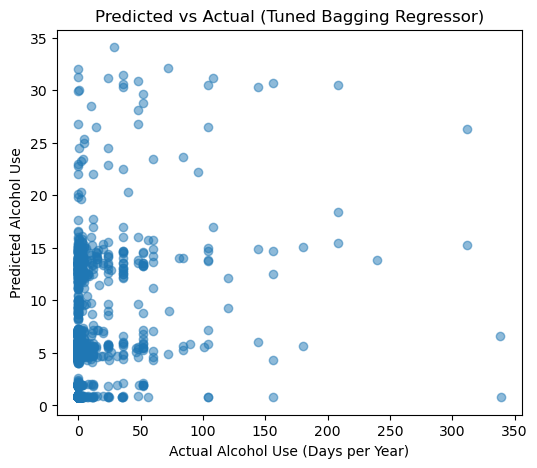

In [58]:
# Predicted vs actual plot
plt.figure(figsize = (6, 5))
plt.scatter(y_test, y_pred_bag, alpha = 0.5)

plt.xlabel("Actual Alcohol Use (Days per Year)")
plt.ylabel("Predicted Alcohol Use")
plt.title("Predicted vs Actual (Tuned Bagging Regressor)")

plt.show()

In [59]:
# Feature importance from tuned decision tree regressor
tree_reg_importance = pd.Series(best_tree_reg.feature_importances_, index=X.columns)
tree_reg_importance = tree_reg_importance.sort_values(ascending = False)

print("Top Features (Decision Tree Regressor):")
print(tree_reg_importance.head(10))

Top Features (Decision Tree Regressor):
STNDALC       0.479203
FRDMJMON      0.299066
YOSTOLE2      0.176708
PRPROUD2      0.030294
STNDSMJ       0.014730
IRSEX         0.000000
NEWRACE2_6    0.000000
NEWRACE2_5    0.000000
NEWRACE2_4    0.000000
NEWRACE2_3    0.000000
dtype: float64


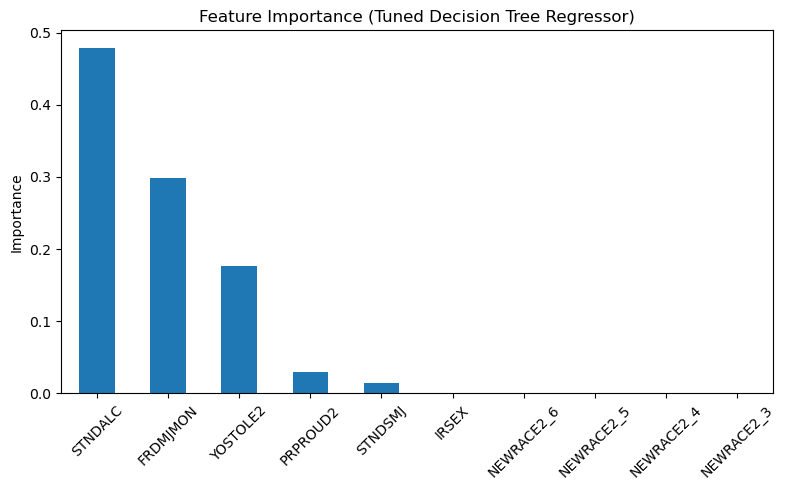

In [60]:
# Plot feature importance
plt.figure(figsize = (8, 5))
tree_reg_importance.head(10).plot(kind = 'bar')

plt.title("Feature Importance (Tuned Decision Tree Regressor)")
plt.ylabel("Importance")

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

### Summary
- The decision tree regressor produced an RMSE of approximately 30.33, and the bagging regressor reduced the RMSE to approximately 22.67. RMSE represents the average prediction error in terms of the number of days alcohol was used in the past year.
    - This means that the decision tree model’s predictions were off by about 30 days on average, while the bagging model reduced this error to about 23 days.
- This reduction in RMSE suggests that ensemble methods are more effective for this regression task, as they reduce variance and produce more stable predictions compared to a single decision tree.
- Feature importance results from the decision tree regressor indicate that demographic, socioeconomic, family, and behavioral variables all play an important role in predicting alcohol use frequency. These findings are consistent with the other classification models, suggesting that similar factors influence both whether youth use alcohol and how frequently they use it.

## Model Comparison and Discussion

In [61]:
# Binary
y_test_binary = y_test
y_pred_tree_binary = y_pred_tree
y_pred_rf_binary = y_pred_rf

# Multi-class
y_test_multi = y_test
y_pred_tree_multi = y_pred_tree_multi
y_pred_gb_multi = y_pred_gb

# Regression
y_test_reg = y_test

In [69]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score
)

# Binary Classification Models
binary_results = pd.DataFrame({
    'Model': ['Decision Tree (Binary)', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test_binary, y_pred_tree_binary),
        accuracy_score(y_test_binary, y_pred_rf_binary)
    ],
    'Balanced Accuracy': [
        balanced_accuracy_score(y_test_binary, y_pred_tree_binary),
        balanced_accuracy_score(y_test_binary, y_pred_rf_binary)
    ],
    'Precision': [
        precision_score(y_test_binary, y_pred_tree_binary, average='weighted', zero_division = 0),
        precision_score(y_test_binary, y_pred_rf_binary, average='weighted', zero_division = 0)
    ],
    'Recall': [
        recall_score(y_test_binary, y_pred_tree_binary, average='weighted', zero_division = 0),
        recall_score(y_test_binary, y_pred_rf_binary, average='weighted', zero_division = 0)
    ],
    'F1 Score': [
        f1_score(y_test_binary, y_pred_tree_binary, average='weighted', zero_division = 0),
        f1_score(y_test_binary, y_pred_rf_binary, average='weighted', zero_division = 0)
    ]
})

# Multi-Class Models
multi_results = pd.DataFrame({
    'Model': ['Decision Tree (Multi)', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test_multi, y_pred_tree_multi),
        accuracy_score(y_test_multi, y_pred_gb_multi)
    ],
    'Balanced Accuracy': [
        balanced_accuracy_score(y_test_multi, y_pred_tree_multi),
        balanced_accuracy_score(y_test_multi, y_pred_gb_multi)
    ],
    'Macro F1': [
        f1_score(y_test_multi, y_pred_tree_multi, average='macro', zero_division = 0),
        f1_score(y_test_multi, y_pred_gb_multi, average='macro', zero_division = 0)
    ],
    'Weighted F1': [
        f1_score(y_test_multi, y_pred_tree_multi, average='weighted', zero_division = 0),
        f1_score(y_test_multi, y_pred_gb_multi, average='weighted', zero_division = 0)
    ]
})

# Regression Models
regression_results = pd.DataFrame({
    'Model': ['Decision Tree Regressor', 'Bagging Regressor'],
    'CV RMSE': [
        -tree_reg_grid.best_score_,
        -bag_grid.best_score_
    ],
    'Test RMSE': [
        tree_rmse,
        bag_rmse
    ]
})

binary_results = binary_results.round(4)
multi_results = multi_results.round(4)
regression_results = regression_results.round(4)

print("\n Binary Classification Results:")
display(binary_results)

print("\n Multi-Class Classification Results:")
display(multi_results)

print("\n Regression Results:")
display(regression_results)


 Binary Classification Results:


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score
0,Decision Tree (Binary),0.7288,0.0200,0.6564,0.7288,0.6900
1,Random Forest,0.7136,0.0207,0.6581,0.7136,0.6835



 Multi-Class Classification Results:


,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
0,Decision Tree (Multi),0.7707,0.0193,0.0177,0.7097
1,Gradient Boosting,0.7880,0.0191,0.0175,0.7173



 Regression Results:


,Model,CV RMSE,Test RMSE
0,Decision Tree Regressor,17.9997,20.4466
1,Bagging Regressor,17.9186,20.2518


### Interpretation
- Across all models several patterns were consistent in terms of predictors of youth alcohol use.
    - Peer related variables, such as friends alchohol (FRDADLY2) and friends marijuana use (FRDMJMON), were some of the most inluential features in both classification and regression models. Suggesting that social environment plays a key role in youth alcohol behavior and usage.
    - Perceived risk of alcohol (STNDALC) and marijuana (STNDSMJ) also appeared as important predictors, which suggests that attitudes toward substance use may influence decision-making.
    - Family-related variables, including parental monitoring (PARCHKHW), parental help with homework (PARHLPHW), and parental expressions of pride (PRPROUD2), also appeared to be important across models.
    - Socioeconomic variables such as household income (INCOME) and poverty level (POVERTY3) were also relevant, suggesting that alcohol use in youths is influenced not only by individual and social factors, but also by more broad environmental conditions.
- Overall, the results suggest that youth alcohol usage is not driven by a single factor, but rather reflects a combination of peer influence, family context, individual attitudes, and socioeconomic conditions.

### Summary of Model Performance
- Across all classification models, overall accuracy values, a measure of the proportion of correct predictions, appeared relatively high randing from $\approx$ 0.71 to $\approx$ 0.91 depending on the model and task. However, accuracy alone was misleading due to severe class imbalance in the dataset, as models could achieve high accuracy by primarily predicting the majority class.
- To address this, additional evaluation metrics were considered.
    - Balanced accuracy, which averages recall across all classes to account for imbalance, was extremely low $\approx$ 0.02 across all models, indicating poor performance in predicting minority classes.
    - F1 scores, which balance precision and recall  were also very low for minority categories.
    - For the multi-class models, macro F1-score, which treats all classes equally, showed that the models performed poorly across less frequently categories.
    - Weighted F1-score, which reflects overall performance by accounting for class size, remained higher due the majority class.
- For the classification models, Random Forest slightly improved performance over the Decision Tree for the binary task. Gradient boosting achieved the highest overall accuracy for the multi-class problem. However, these improvements were minimal when evaluated using balanced accuracy and F1-score, suggesting that none of the models effectively addressed class imbalance.
- For the regression task, model performance was evaluated using Root Mean Squared Error (RMSE), which measures the average magnitude of prediction error in the same units as the response variable. Both models produced similar results, with RMSE values around 20 on the test set.
    - The Bagging Regressor slightly outperformed the single Decision Tree, indicating that ensemble methods can reduce variance and improve predictive stability.


### Effect of Variable Type on Prediction
- Some variables in this dataset represent similar underlying information but can be encoded in different ways, such as binary, ordinal, or numeric formats.
    - Binary variables, such as parental involvement (PARCHKHW, PARHLPHW) or peer behavior (FRDADLY2, FRDMJMON), simplify information into two categories.
        - Easy to interpret and useful when the distinction between two groups is meaningful.
        - Binary encoding may lose information if the variable originally had more details.
    - Ordinal variables, such as income (INCOME), poverty level (POVERTY3), and perceived risk (STNDALC, STNDSMJ), preserve the natural ordering of categories.
        - Allows models to recognize relative differences, which can improve predictions when ordering has meaningful progression.
        -  However, ordinal encoding assumes consistent spacing between categories, which may not always be accurate.
    - Numerical variables provide the most detailed representation, capturing continuous variation in the data
        - This allows models to capture fine-grained differences in behavior.
        - May also introduce noise if the data is highly skewed or contains a lot of zero values.
- Overall, binary encoding is appropriate when only two categories are meaningful, ordinal encoding is useful when there is a ranking, and numeric encoding is best when the variable represents a continuous quantity.

### Comparison of Tree-based Models
- Across all three tasks, ensemble methods improved performance over single decision trees. This is in line with the theory that single trees are easy to interpret but can have high variance, while ensemble methosd reduce variance bu combining many trees.
    - For binary classification, random forest model slightly improved performance over the single decision tree.
        - Both models showed low balanced accuracy, suggesting that neither of them performed well across both classes and that it does not address the underlying class imbalance in the data.
    - For the multi-class classification task, Gradient Boosting achieved the highest overall accuracy.
        - However, evaluation metrics such as balanced accuracy and macro F1-score, along with the confusion matrix, showed that the model overwhelmingly predicted the majority class. Because of this, the improvement in accuracy does not reflect meaningful performance across all alcohol use categories, particularly for moderate and high use.
    - For the regression task, the Bagging Regressor provided a small but consistent improvement over the Decision Tree Regressor, with slightly lower RMSE values.
        - This indicates that ensemble averaging helped stabilize predictions and reduce variance, leading to better generalization on unseen data.

### Limitations
- This analysis currently has several limitations.
    - First, the multi-class target was highly imbalanced, with most respondents falling into the "No Use" category. This impacted model performance, shown by the low balanced accuracy and macro F1-scores.
        - Because of this, models were unable to effectively distinguish between low, moderate, and high alcohol use, limiting their usefulness.
    - Second, the predictor set was intentionally limited to a smaller group of variables to maintain interpretability.
        - While this made the models easier to understand and communicate, it's possible that it may have excluded other factors tjat could have improved model performance.
    - Third, although tree-based models identify associations, they do not establish causation. Variables such as race/ethnicity, income, and family characteristics should be interpreted as correlated with alcohol use, not as direct causes.

- Potential improvements could include:
    - Addressing class imbalance through resampling or class-weighted methods.
    - Tuning hyperparameters more extensively.
    - Including additional relevant predictors from the broader dataset.
    - Comparing tree-based models to non-tree models for a broader benchmark